# 05 — Evaluation
CS2 Match Outcome Predictor & Seeding Engine

Goals:
1. Calibration check (reliability diagram, Brier score)
2. Prediction symmetry test — P(A,B) + P(B,A) ≈ 1
3. Sparse/new-team behavior test
4. Error analysis — where does the model fail most?

In [1]:
import os

# === For Colab: clone the repo if not already present ===
# if not os.path.exists('CS2-Capstone-Project') and 'CS2-Capstone-Project' not in os.getcwd():
#     try:
#         import google.colab
#         !git clone https://github.com/AzizkhonM/CS2-Capstone-Project.git
#         os.chdir('CS2-Capstone-Project')
#         print("Colab: repo clone qilindi va CWD o'zgartirildi")
#     except ImportError:
#         pass

# === For VS Code / local Jupyter: find repo root automatically ===
def find_repo_root(marker='requirements.txt'):
    path = os.getcwd()
    while True:
        if os.path.exists(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError(f"Could not find repo root (looking for '{marker}')")
        path = parent

repo_root = find_repo_root()
os.chdir(repo_root)

os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\User\Desktop\CS model\cs2-seeding-capstone


In [2]:
import logging
import time
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

try:
    import google.colab
    logging.Formatter.converter = lambda *args: time.localtime(time.time() + 5*3600)
except ImportError:
    pass

logging.basicConfig(
    filename='data/05_evaluation.log',
    level=logging.INFO,
    format='%(asctime)s - %(message)s',
    filemode='a',
    force=True
)

logging.info("=" * 60)
logging.info("NEW RUN STARTED")
logging.info("=" * 60)

In [3]:
df = pd.read_csv('data/matches_with_elo.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

with open('models/logreg_model.pkl', 'rb') as f:
    logreg = pickle.load(f)

with open('models/feature_list.pkl', 'rb') as f:
    final_features = pickle.load(f)

print("Data shape:", df.shape)
print("Features:", len(final_features))
logging.info(f"Loaded data {df.shape}, model, {len(final_features)} features")

Data shape: (6989, 59)
Features: 20


## 1. Rebuild features (using src/features.py — same logic as 04_model_training)

In [4]:
import sys
sys.path.append('.')
from src.features import build_features

In [5]:
df, final_features = build_features(df)
df['team1_won'] = (df['winner'] == 'team1').astype(int)

split_date = df['date'].quantile(0.8, interpolation='nearest')
train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

X_train, y_train = train_df[final_features].fillna(0), train_df['team1_won']
X_test, y_test = test_df[final_features].fillna(0), test_df['team1_won']

print(f"Split date: {split_date}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
logging.info(f"Rebuilt features: {len(final_features)} | Train: {X_train.shape} | Test: {X_test.shape}")

Split date: 2025-09-04 13:30:00+00:00
Train: (5590, 20), Test: (1399, 20)


## 2. Recreate the same scaling used in training

(StandardScaler must be fit on train, applied to test — same as 04_model_training)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

probs = logreg.predict_proba(X_test_scaled)[:, 1]
preds = logreg.predict(X_test_scaled)

print("Recomputed test predictions ready.")
logging.info("Recomputed scaled test predictions using loaded model")

Recomputed test predictions ready.


## 3. Calibration check

Does a predicted 70% probability actually correspond to a ~70% real win rate?

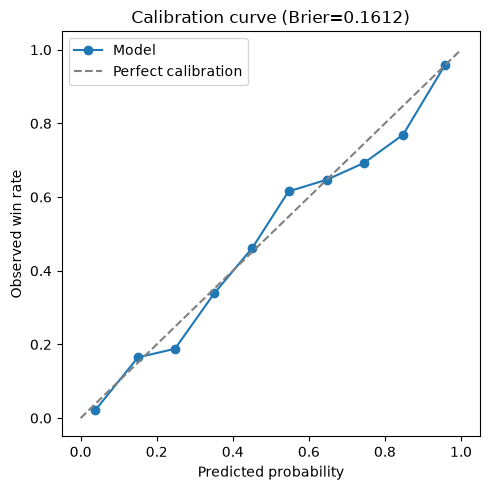

Brier score: 0.1612


In [7]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, probs)
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(prob_pred, prob_true, marker='o', label='Model')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed win rate')
ax.set_title(f'Calibration curve (Brier={brier:.4f})')
ax.legend()
plt.tight_layout()
plt.savefig('results/calibration_curve.png')
plt.show()

print(f"Brier score: {brier:.4f}")
logging.info(f"Brier score: {brier:.4f}")

## 4. Prediction symmetry test

For a sample of team pairs, check whether P(A beats B) + P(B beats A) ≈ 1.

In [8]:
def predict_pair(team_a_row, team_b_row_swapped, model, scaler, feature_cols):
    """Predicts P(team1 wins) for a single-row feature vector."""
    X = pd.DataFrame([team_a_row[feature_cols]])
    X_scaled = pd.DataFrame(scaler.transform(X), columns=feature_cols)
    return model.predict_proba(X_scaled)[0][1]

sample = test_df.sample(n=min(30, len(test_df)), random_state=42)

symmetry_errors = []
for idx, row in sample.iterrows():
    p_ab = predict_pair(row, None, logreg, scaler, final_features)

    swapped = row.copy()
    for base in ['elo_diff'] + [c for c in final_features if c.endswith('_diff')]:
        if base in swapped:
            swapped[base] = -swapped[base]

    p_ba = predict_pair(swapped, None, logreg, scaler, final_features)

    symmetry_errors.append(abs((p_ab + p_ba) - 1))

symmetry_errors = pd.Series(symmetry_errors)
print("Symmetry check — |P(A,B) + P(B,A) - 1|:")
print(symmetry_errors.describe())
logging.info(f"Symmetry error mean={symmetry_errors.mean():.4f}, max={symmetry_errors.max():.4f}")

Symmetry check — |P(A,B) + P(B,A) - 1|:
count    30.000000
mean      0.039922
std       0.034670
min       0.000432
25%       0.014081
50%       0.033142
75%       0.060928
max       0.125664
dtype: float64


## 5. Sparse/new-team behavior test

Compare model accuracy for teams with few historical matches vs. established teams.

In [9]:
match_counts = pd.concat([
    df.groupby('team1_name').size(),
    df.groupby('team2_name').size()
]).groupby(level=0).sum()

test_df['team1_match_count'] = test_df['team1_name'].map(match_counts)
test_df['team2_match_count'] = test_df['team2_name'].map(match_counts)
test_df['min_match_count'] = test_df[['team1_match_count', 'team2_match_count']].min(axis=1)

test_df['pred'] = preds
test_df['correct'] = (test_df['pred'] == y_test.values).astype(int)

sparse = test_df[test_df['min_match_count'] < 10]
established = test_df[test_df['min_match_count'] >= 10]

print(f"Sparse-history matches (<10 games): {len(sparse)}, accuracy: {sparse['correct'].mean():.4f}")
print(f"Established matches (>=10 games): {len(established)}, accuracy: {established['correct'].mean():.4f}")

logging.info(f"Sparse-history accuracy: {sparse['correct'].mean():.4f} (n={len(sparse)})")
logging.info(f"Established accuracy: {established['correct'].mean():.4f} (n={len(established)})")

Sparse-history matches (<10 games): 223, accuracy: 0.9327
Established matches (>=10 games): 1176, accuracy: 0.7262


## 6. Error analysis

Where does the model fail most — by event type and by prediction confidence?

In [10]:
test_df['pred_proba'] = probs
test_df['confidence'] = np.abs(test_df['pred_proba'] - 0.5) * 2

print("Accuracy by event_type:")
print(test_df.groupby('event_type')['correct'].mean())

print("\nAccuracy by confidence bucket:")
test_df['confidence_bucket'] = pd.cut(test_df['confidence'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0])
print(test_df.groupby('confidence_bucket', observed=True)['correct'].mean())

logging.info("Error analysis by event_type and confidence bucket computed")

Accuracy by event_type:
event_type
lan       0.732323
online    0.769691
Name: correct, dtype: float64

Accuracy by confidence bucket:
confidence_bucket
(0.0, 0.2]    0.577558
(0.2, 0.4]    0.653696
(0.4, 0.6]    0.735294
(0.6, 0.8]    0.795349
(0.8, 1.0]    0.966321
Name: correct, dtype: float64


## 7. Save evaluation summary

In [11]:
summary = {
    'brier_score': brier,
    'symmetry_error_mean': symmetry_errors.mean(),
    'symmetry_error_max': symmetry_errors.max(),
    'sparse_accuracy': sparse['correct'].mean(),
    'established_accuracy': established['correct'].mean(),
}

pd.Series(summary).to_csv('results/evaluation_summary.csv')
logging.info(f"Saved evaluation_summary.csv: {summary}")
print(summary)

{'brier_score': 0.1611937615190473, 'symmetry_error_mean': np.float64(0.03992215448080865), 'symmetry_error_max': np.float64(0.1256635690832657), 'sparse_accuracy': np.float64(0.9327354260089686), 'established_accuracy': np.float64(0.7261904761904762)}


In [12]:
try:
    from google.colab import files
    files.download('results/calibration_curve.png')
    files.download('results/evaluation_summary.csv')
    files.download('data/05_evaluation.log')
except ImportError:
    print("Not running in Colab.")

Not running in Colab.
